importacion de las librerias

In [125]:
import torch 
import pandas as  pd
import numpy as np
from matplotlib import pyplot
from scipy import optimize
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim

carga del dataset

In [126]:
# Cargar CSV
data = pd.read_csv("./Dry_Bean_Dataset.csv")

print(data.head())
print(data.info())
print(data['Class'].value_counts())


    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

In [127]:
mapping = {
    'DERMASON': 0,
    'SIRA': 1,
    'SEKER': 2,
    'HOROZ': 3,
    'CALI': 4,
    'BARBUNYA': 5,
    'BOMBAY': 6
}

data['Class_num'] = data['Class'].map(mapping)


In [128]:
data.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class,Class_num
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER,2
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER,2
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER,2
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER,2
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER,2


In [129]:
X = data.drop(columns=["Class", "Class_num"]).values
y = data['Class_num'].values


In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # mantiene distribución de clases
)

print("Tamaño train:", X_train.shape, y_train.shape)
print("Tamaño test:", X_test.shape, y_test.shape)


Tamaño train: (10888, 16) (10888,)
Tamaño test: (2723, 16) (2723,)


normalizacion de los datos

In [131]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma


convertir a tensores

In [132]:
X_train_tensor = torch.from_numpy(X_train_norm).float()
y_train_tensor = torch.from_numpy(y_train).long()
X_test_tensor = torch.from_numpy(X_test_norm).float()
y_test_tensor = torch.from_numpy(y_test).long()

In [133]:
class ModelCustom2(nn.Module):
    def __init__(self, D_in, H, D_out):
        super(ModelCustom2, self).__init__()
        self.fc1 = nn.Linear(D_in, H)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(H, D_out)

    def forward(self, x):
        x1 = self.fc1(x)
        x = self.relu(x1)
        x = self.fc2(x + x1)
        return x



In [134]:

model = ModelCustom2(D_in=16, H=100, D_out=7)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.2)


epochs = 100
log_each = 10
losses = []

model.train()
for e in range(1, epochs+1):
    # Forward
    y_pred = model(X_train_tensor)

    # Calcular loss
    loss = criterion(y_pred, y_train_tensor)
    losses.append(loss.item())

    # Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if e % log_each == 0:
        print(f"Epoch {e}/{epochs}, Loss: {np.mean(losses):.5f}")





Epoch 10/100, Loss: 0.82905
Epoch 20/100, Loss: 0.61551
Epoch 30/100, Loss: 0.51713
Epoch 40/100, Loss: 0.45856
Epoch 50/100, Loss: 0.41918
Epoch 60/100, Loss: 0.39071
Epoch 70/100, Loss: 0.36908
Epoch 80/100, Loss: 0.35205
Epoch 90/100, Loss: 0.33827
Epoch 100/100, Loss: 0.32687


In [136]:
from sklearn.metrics import accuracy_score


model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor)
    y_pred_labels = torch.argmax(y_pred_test, dim=1)

accuracy = accuracy_score(y_test, y_pred_labels.numpy())
print("Precisión en test:", accuracy)

Precisión en test: 0.9144326110907087


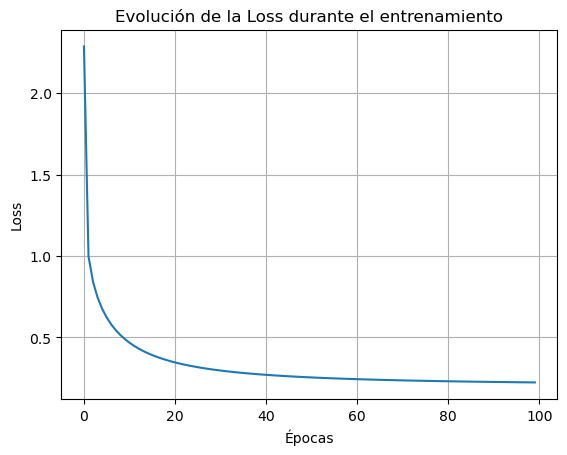

In [137]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Evolución de la Loss durante el entrenamiento")
plt.grid(True)
plt.show()


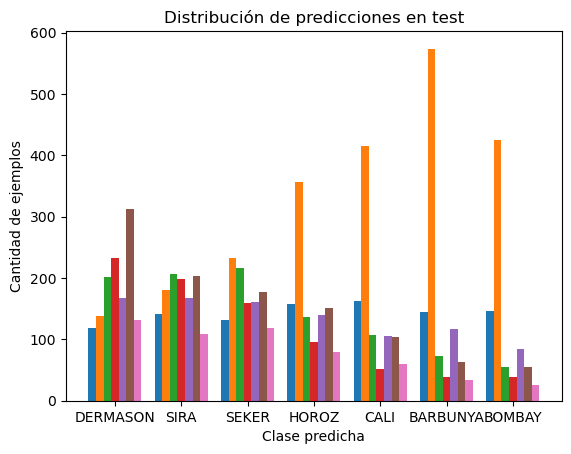

In [139]:
plt.hist(y_pred_test.numpy(), bins=np.arange(8)-0.5, rwidth=0.8)
plt.xticks(range(7), mapping.keys())
plt.xlabel("Clase predicha")
plt.ylabel("Cantidad de ejemplos")
plt.title("Distribución de predicciones en test")
plt.show()
